# Implementing changes to PrEP

## First, some scenarios showing various modes of PrEP distribution

In [17]:
import hivsim
import stisim as sti
import starsim as ss
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def make_sim(interventions, label):
    sim = hivsim.demo(
        'simple', run=False, plot=False, n_agents=n_agents, dur=dur,
        networks=[sti.StructuredSexual(), ss.MaternalNet(), ss.BreastfeedingNet()],
    )
    hiv_test = sti.HIVTest(name='hiv_test', test_prob_data=0.3)
    art = sti.ART(coverage=0.6)
    sim.pars.interventions = [hiv_test, art] + list(interventions)
    sim.label = label
    return sim

def bin_timeseries(timevec, values, bin_size=6, agg='mean'):
    """
    Downsample a time series into non-overlapping chunks of bin_size steps.
    Use agg='mean' for rates (e.g. prevalence) and agg='sum' for per-step
    counts (e.g. new_infections), so a count bin means "total over the
    window" rather than being diluted by averaging. Drops any leftover
    steps that don't fill a full bin.
    """
    values = np.asarray(values)
    n = len(values) - (len(values) % bin_size)
    values = values[:n].reshape(-1, bin_size)
    timevec = np.asarray(timevec)[:n].reshape(-1, bin_size)
    binned_time = timevec.mean(axis=1)
    binned_values = values.mean(axis=1) if agg == 'mean' else values.sum(axis=1)
    return binned_time, binned_values


def total_new_prep(sim):
    """Sum new_prep across every Prep instance in the sim (all-zero if none,
    e.g. the no-PrEP scenario) -- a scenario can have more than one product."""
    total = np.zeros(len(sim.t.yearvec))
    for intv in sim.interventions():
        if isinstance(intv, sti.Prep):
            total += np.asarray(intv.results.new_prep)
    return total

In [35]:
n_agents = 10_000
dur = 15

# 1. No PrEP (baseline)
scenario_none = []

# 2. Oral PrEP: 10% of women 15-35, 3-month courses, 85% efficacy, 75% adherence.
#    Flat coverage + an eligibility filter (Prep defaults to FSW-only otherwise).
prep_coverage = pd.DataFrame({
    'Year': [2000,2004,2005, 2025],
    'AgeBin': ['[15,35)','[15,35)','[15,35)','[15,35)'],
    'Gender': ['f','f','f','f'],
    'n_prep': [0,0,25,25]
})
prep_oral = sti.Prep(
    prep_eff=0.85, prep_dur=ss.months(3), prep_adh=1.0,
    coverage = prep_coverage,
    eligibility=lambda sim: sim.people.female & (sim.people.age >= 15) & (sim.people.age < 35),
    name='prep_oral',
)

#prep_oral = sti.Prep(
#    prep_eff=0.85, prep_dur=ss.months(3), prep_adh=1.0,
#    coverage=0.5,
#    eligibility=lambda sim: sim.people.female & (sim.people.age >= 15) & (sim.people.age < 35),
#    name='prep_oral',
#)
scenario_oral = [prep_oral]

# 3. Long-acting PrEP: 500 men + 1000 women aged 15-35, 12-month courses,
#    100% efficacy/adherence. Numbers differ by sex, so this needs an
#    age/sex-stratified absolute-count (n_prep) coverage target rather than
#    a flat fraction.
la_coverage = pd.DataFrame({
    'Year':   [2000, 2000, 2005, 2005],
    'AgeBin': ['[15,35)', '[15,35)', '[15,35)', '[15,35)'],
    'Gender': ['m', 'f','m', 'f'],
    'n_prep': [0,0, 50, 100],
})
prep_la = sti.Prep(
    prep_eff=1.0, prep_dur=ss.months(12), prep_adh=1.0,
    coverage=la_coverage,
    eligibility=lambda sim: sim.people.alive,  # age/sex restriction comes from la_coverage's strata
    name='prep_la',
)
scenario_la = [prep_la]

scenarios = {
    'No PrEP': scenario_none,
    'Oral PrEP (10% women 15-35)': scenario_oral,
    'Long-acting PrEP (500M/1000F, 15-35)': scenario_la,
}

sims = [make_sim(intvs, label) for label, intvs in scenarios.items()]
for sim in sims:
    sim.run(verbose=0)

Initializing sim "No PrEP" with 10000 agents
Initializing sim "Oral PrEP (10% women 15-35)" with 10000 agents
Initializing sim "Long-acting PrEP (500M/1000F, 15-35)" with 10000 agents


In [36]:
for sim in sims:
    hiv = sim.results.hiv
    t, prev = bin_timeseries(sim.t.yearvec, hiv.prevalence, bin_size=6, agg='mean')
    _, new_inf = bin_timeseries(sim.t.yearvec, hiv.new_infections, bin_size=6, agg='sum')
    t_annual, new_prep = bin_timeseries(sim.t.yearvec, total_new_prep(sim), bin_size=12, agg='sum')
    axes[0].plot(t, prev, label=sim.label)
    axes[1].plot(t, new_inf, label=sim.label)
    axes[2].plot(t_annual, new_prep, label=sim.label)

No PrEP                                  final prevalence=0.1214  cum_infections=1305
Oral PrEP (10% women 15-35)              final prevalence=0.1214  cum_infections=1304
Long-acting PrEP (500M/1000F, 15-35)     final prevalence=0.1186  cum_infections=1268


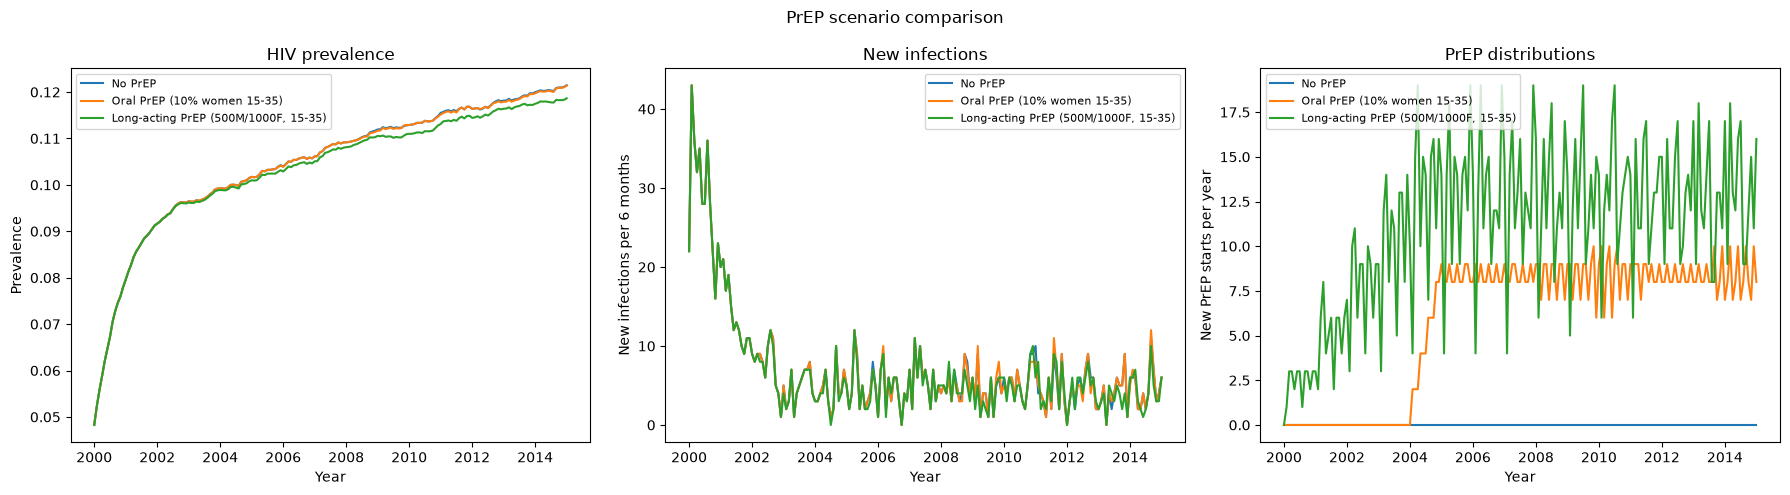

In [37]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for sim in sims:
    hiv = sim.results.hiv
    axes[0].plot(sim.t.yearvec, hiv.prevalence, label=sim.label)
    axes[1].plot(sim.t.yearvec, hiv.new_infections, label=sim.label)
    axes[2].plot(sim.t.yearvec, total_new_prep(sim), label=sim.label)

axes[0].set_title('HIV prevalence')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Prevalence')
axes[1].set_title('New infections')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('New infections per 6 months')
axes[2].set_title('PrEP distributions')
axes[2].set_xlabel('Year')
axes[2].set_ylabel('New PrEP starts per year')
for ax in axes:
    ax.legend(fontsize=8)
fig.suptitle('PrEP scenario comparison')
fig.tight_layout()
#plt.savefig('prep_test_scenarios.png', dpi=150)
#print('Saved figure to prep_test_scenarios.png')

for sim in sims:
    hiv = sim.results.hiv
    print(f'{sim.label:40s} final prevalence={hiv.prevalence[-1]:.4f}  '
          f'cum_infections={int(hiv.cum_infections[-1])}')

plt.show()

In [33]:
sims[0].results.hiv.prevalence

Result(HIV.prevalence):
array([0.04827181 0.05237396 0.05579441 0.05885224 0.06204344 0.06465727
 0.06723669 0.07051406 0.07282588 0.07462542 0.07600193 0.07799094
 0.07959577 0.08129925 0.08271759 0.08444359 0.08564593 0.08651642
 0.08749165 0.08843991 0.08899676 0.08963878 0.09045178 0.09124503
 0.09164931 0.09204427 0.09268707 0.09310442 0.09366157 0.09393254
 0.09481216 0.09553362 0.09598948 0.09626572 0.09623313 0.09617005
 0.09647235 0.09637315 0.09639455 0.09669591 0.09656652 0.09680127
 0.09703579 0.09741773 0.09793142 0.09833318 0.09899516 0.09919122
 0.09927563 0.09922107 0.09917661 0.09950065 0.1        0.1000461
 0.09996315 0.0997699  0.10065323 0.10081719 0.10096198 0.10147314
 0.10171815 0.10164384 0.10174286 0.1022955  0.10300273 0.1029158
 0.10323225 0.10323868 0.10333575 0.10340456 0.10390081 0.1042307
 0.10396174 0.10447089 0.1050405  0.10496989 0.10539546 0.10536227
 0.10567357 0.10582863 0.10595494 0.10558285 0.1058834  0.10569976
 0.10614027 0.10618208 0.10699991 0

## PrEP Duration Check

Making sure that people stay on PrEP for the amount of time we tell them to

In [42]:
class OneTimePrepEnrollment(ss.Intervention):
    """Enrolls everyone once at t=0, then only ever expires courses (never
    tops back up) -- unlike sti.Prep's continuous stock-target coverage,
    which would immediately re-enroll people the same step they expire,
    masking the drop in n_on_prep. Expiry isn't automatic on HIV's side --
    each Prep-like instance is responsible for calling stop_prep() on its
    own enrollees every step (mirrors Prep.step())."""
    def __init__(self, eff, dur, adh=1.0):
        super().__init__()
        self.eff, self.dur, self.adh = eff, dur, adh
        self._source_id = -1
        self._enrolled = False

    def step(self):
        hiv = self.sim.diseases.hiv
        if not self._enrolled:
            hiv.start_prep(self.sim.people.alive.uids, eff=self.eff, dur=self.dur,
                            source_id=self._source_id, adh=self.adh)
            self._enrolled = True
        else:
            expiring = hiv.on_prep & (hiv.prep_source == self._source_id) & (hiv.ti_prep_stop <= self.ti)
            if expiring.any():
                hiv.stop_prep(expiring.uids)
        return


sim_dur = hivsim.demo(
    'simple', run=False, plot=False, n_agents=100, dur=3,
    networks=[sti.StructuredSexual(), ss.MaternalNet(), ss.BreastfeedingNet()],
)
sim_dur.pars.interventions = [OneTimePrepEnrollment(eff=0.9, dur=ss.months(9))]
sim_dur.run(verbose=0)


Initializing sim with 100 agents


Sim(n=100; 2000—2003.0; demographics=pregnancy, deaths; networks=structuredsexual, maternalnet, breastfeedingnet; diseases=hiv; interventions=onetimeprepenrollment)

In [52]:
timevec[enrolled_idx] + 3/4

2000.833333333

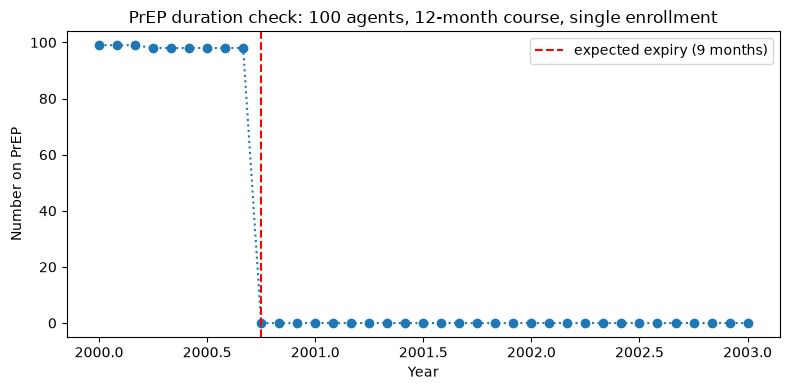

In [54]:
timevec = sim_dur.t.yearvec  # plain float years -- hiv.timevec is a DateArray, awkward for arithmetic
n_on_prep = np.asarray(sim_dur.results.hiv.n_on_prep)
enrolled_idx = 0 

fig2, ax = plt.subplots(figsize=(8, 4))
ax.plot(timevec, n_on_prep, linestyle=':')
ax.scatter(timevec, n_on_prep)
ax.axvline(timevec[enrolled_idx] + 9/12, color='red', linestyle='--', label='expected expiry (9 months)')
ax.set_xlabel('Year')
ax.set_ylabel('Number on PrEP')
ax.set_title('PrEP duration check: 100 agents, 12-month course, single enrollment')
ax.legend()
fig2.tight_layout()
#plt.savefig('prep_test_duration_check.png', dpi=150)
#print('Saved figure to prep_test_duration_check.png')

plt.show()

In [40]:
# Look for the bulk expiry (everyone shares the same ti_prep_stop) after
# enrollment, not the pre-enrollment zero baseline or incidental single-agent
# dips from background mortality along the way.
after = n_on_prep[enrolled_idx:]
expiry_idx = enrolled_idx + np.argmax(after < n_on_prep[enrolled_idx] / 2)
expiry_year = timevec[expiry_idx] - timevec[enrolled_idx]
print(f'Enrolled: {int(n_on_prep[enrolled_idx])} agents at year {timevec[enrolled_idx]:.3f}')
print(f'Dropped to {int(n_on_prep[expiry_idx])} agents at year {timevec[expiry_idx]:.3f} '
      f'({expiry_year:.3f} years after enrollment; expected 1.000)')
assert abs(expiry_year - 1.0) < sim_dur.t.dt_year * 1.5, 'PrEP did not expire on schedule'
print('PASS: PrEP expired on schedule.')

Enrolled: 99 agents at year 2000.083
Dropped to 0 agents at year 2001.000 (0.917 years after enrollment; expected 1.000)
PASS: PrEP expired on schedule.
